In [1]:
%matplotlib inline

In [54]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [3]:
#Import your modules here
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
PARSED_DATA_DIR = PROJECT_ROOT / "data" / "parsed_sales_full"

In [4]:
ml_model_base_df = pd.read_parquet(PARSED_DATA_DIR / "imot_ml_ready.parquet")
ml_model_base_df

,ad_id,ad_url,listing_type,property_type_raw,currency,vat_status,title_city_model,title_geo_2_model,geo_category,total_price,area_sqm,price_per_sqm,views,features_count,construction_type_model,construction_year_model,floor_model,total_floors_model,floor_applicability,features_pipe
0,1a129794411209548,https://www.imot.bg/obiava-1a129794411209548-p...,single_property_listing,1-СТАЕН,EUR,no_vat,област благоевград,банско,mountain_resort,36000.0,35.0,1028.57,5834.0,3,Тухла,2010.0,3.0,5.0,applicable,Тухла|Обзаведен|Контрол на достъпа
1,1a127539284802892,https://www.imot.bg/obiava-1a127539284802892-p...,single_property_listing,1-СТАЕН,EUR,no_vat,област добрич,балчик,sea_resort,75000.0,51.0,1470.59,2391.0,8,Тухла,2008.0,3.0,5.0,applicable,Тухла|Асансьор|Интернет връзка|Обзаведен|Видео...
2,1a126881929164804,https://www.imot.bg/obiava-1a126881929164804-p...,single_property_listing,1-СТАЕН,EUR,no_vat,град плевен,дружба 1,regional_city,53500.0,40.0,1337.50,6579.0,1,Панел,2026.0,4.0,8.0,applicable,Панел
3,1a130799086731769,https://www.imot.bg/obiava-1a130799086731769-p...,single_property_listing,1-СТАЕН,EUR,no_vat,град плевен,дружба 4,regional_city,52000.0,40.0,1300.00,4282.0,2,Панел,1970.0,8.0,8.0,applicable,Панел|Асансьор
4,1a140309247069043,https://www.imot.bg/obiava-1a140309247069043-p...,single_property_listing,1-СТАЕН,EUR,unknown,област велико търново,горна оряховица,small_city,49450.0,42.0,1177.38,3.0,14,Панел,2026.0,1.0,6.0,applicable,Панел|С преход|Асансьор|С гараж|С паркинг|Лизи...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159461,1t177883753392599,https://www.imot.bg/obiava-1t177883753392599-p...,single_property_listing,ВИЛНО СЕЛИЩЕ,EUR,with_vat,област бургас,велика,village,659900.0,1680.0,392.80,34.0,1,Тухла,2026.0,NaN,NaN,applicable,Тухла
159462,1t177870422636588,https://www.imot.bg/obiava-1t177870422636588-p...,single_property_listing,ФАБРИКА/ЗАВОД,EUR,without_vat,област кърджали,джебел,small_city,2000000.0,2725.0,733.94,41.0,2,Тухла,2026.0,NaN,NaN,applicable,Тухла|Саниран
159463,1t177882534906657,https://www.imot.bg/obiava-1t177882534906657-p...,single_property_listing,АВТОСЕРВИЗ,EUR,unknown,град варна,тополи,large_regional_city,165800.0,2068.0,80.17,38.0,3,Панел,2026.0,NaN,NaN,applicable,Сглобяема конструкция|С паркинг|С действащ бизнес
159464,1t177876453886021,https://www.imot.bg/obiava-1t177876453886021-p...,single_property_listing,ПАРКИНГ,EUR,with_vat,област софия,ботевград,small_city,3800000.0,12000.0,316.67,49.0,1,Тухла,2026.0,NaN,NaN,applicable,Тухла


In [5]:
residential_property_types = [
    "1-СТАЕН",
    "2-СТАЕН",
    "3-СТАЕН",
    "4-СТАЕН",
    "МНОГОСТАЕН",
    "МЕЗОНЕТ",
    "КЪЩА",
    "ЕТАЖ ОТ КЪЩА",
    "ВИЛА",
    "АТЕЛИЕ, ТАВАН",
]

residential_df = ml_model_base_df[
    ml_model_base_df["property_type_raw"].isin(residential_property_types)
].copy()

residential_df.shape

(107436, 20)

In [6]:
ppm = residential_df["price_per_sqm"].dropna()

ppm_desc = ppm.describe()
ppm_desc

count    107436.000000
mean       1738.996077
std         928.080772
min           1.310000
25%        1159.532500
50%        1571.430000
75%        2204.952500
max       19179.890000
Name: price_per_sqm, dtype: float64

In [7]:
mean_ppm = ppm.mean()
median_ppm = ppm.median()
std_ppm = ppm.std()

mean_ppm, median_ppm, std_ppm

(np.float64(1738.9960773856062),
 np.float64(1571.43),
 np.float64(928.0807718577455))

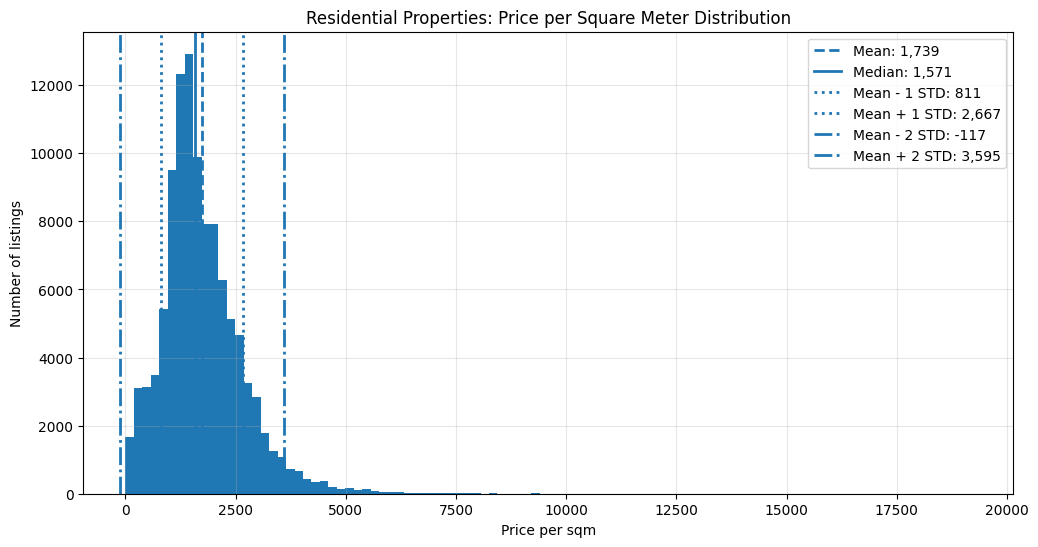

In [8]:
plt.figure(figsize=(12, 6))

plt.hist(ppm, bins=100)

# Mean and median
plt.axvline(mean_ppm, linestyle="--", linewidth=2, label=f"Mean: {mean_ppm:,.0f}")
plt.axvline(median_ppm, linestyle="-", linewidth=2, label=f"Median: {median_ppm:,.0f}")

# ±1 standard deviation
plt.axvline(mean_ppm - std_ppm, linestyle=":", linewidth=2, label=f"Mean - 1 STD: {mean_ppm - std_ppm:,.0f}")
plt.axvline(mean_ppm + std_ppm, linestyle=":", linewidth=2, label=f"Mean + 1 STD: {mean_ppm + std_ppm:,.0f}")

# ±2 standard deviations
plt.axvline(mean_ppm - 2 * std_ppm, linestyle="-.", linewidth=2, label=f"Mean - 2 STD: {mean_ppm - 2 * std_ppm:,.0f}")
plt.axvline(mean_ppm + 2 * std_ppm, linestyle="-.", linewidth=2, label=f"Mean + 2 STD: {mean_ppm + 2 * std_ppm:,.0f}")

plt.title("Residential Properties: Price per Square Meter Distribution")
plt.xlabel("Price per sqm")
plt.ylabel("Number of listings")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
features_series = (
    residential_df["features_pipe"]
    .dropna()
    .astype(str)
    .str.split("|")
    .explode()
    .str.strip()
)

features_series = features_series[features_series != ""]

residential_features_counts = (
    features_series
    .value_counts()
    .rename_axis("feature")
    .reset_index(name="count")
)

residential_features_counts["share_of_residential_listings"] = (
    residential_features_counts["count"] / len(residential_df)
)

residential_features_counts

,feature,count,share_of_residential_listings
0,Тухла,95707,0.890828
1,Асансьор,53429,0.497310
2,Контрол на достъпа,35131,0.326995
3,Обзаведен,28230,0.262761
4,С паркинг,27684,0.257679
...,...,...,...
357,-4-ти (последен) жилищен етаж,1,0.000009
358,Прекрасен двор,1,0.000009
359,Изложение: Ю,1,0.000009
360,Имот с потенциал за разширяване или ново строи...,1,0.000009


In [10]:
print("Residential rows:", len(residential_df))
print("Rows with non-empty features_pipe:", residential_df["features_pipe"].notna().sum())
print("Unique residential features:", residential_features_counts.shape[0])

residential_features_counts.head(75)

Residential rows: 107436
Rows with non-empty features_pipe: 107436
Unique residential features: 362


,feature,count,share_of_residential_listings
0,Тухла,95707,0.890828
1,Асансьор,53429,0.497310
2,Контрол на достъпа,35131,0.326995
3,Обзаведен,28230,0.262761
4,С паркинг,27684,0.257679
...,...,...,...
70,Устройствени показатели (зона Жм):,1,0.000009
71,Плътност на застрояване: 40%,1,0.000009
72,"КИНТ: 1,3",1,0.000009
73,Минимална озеленена площ: 40%,1,0.000009


In [11]:
feature_cutoff_diagnostics = residential_features_counts.copy()

feature_cutoff_diagnostics["cumulative_count"] = feature_cutoff_diagnostics["count"].cumsum()
feature_cutoff_diagnostics["cumulative_share_of_feature_mentions"] = (
    feature_cutoff_diagnostics["cumulative_count"] /
    feature_cutoff_diagnostics["count"].sum()
)

feature_cutoff_diagnostics.head(100)

,feature,count,share_of_residential_listings,cumulative_count,cumulative_share_of_feature_mentions
0,Тухла,95707,0.890828,95707,0.263879
1,Асансьор,53429,0.497310,149136,0.411191
2,Контрол на достъпа,35131,0.326995,184267,0.508052
3,Обзаведен,28230,0.262761,212497,0.585887
4,С паркинг,27684,0.257679,240181,0.662216
...,...,...,...,...,...
95,- Сградите се намират в старата част на кварта...,1,0.000009,362427,0.999267
96,-Съдействие на наши клиенти за кредитиране при...,1,0.000009,362428,0.999269
97,-Без допълнителни комисионни от купувач.,1,0.000009,362429,0.999272
98,-Няма такса поддръжка за сградите.,1,0.000009,362430,0.999275


In [12]:
for cutoff in [10, 25, 50, 100, 250, 500, 1000]:
    n_features = (residential_features_counts["count"] >= cutoff).sum()
    print(f"cutoff >= {cutoff:>4}: {n_features:>3} features")

cutoff >=   10:  25 features
cutoff >=   25:  25 features
cutoff >=   50:  24 features
cutoff >=  100:  23 features
cutoff >=  250:  22 features
cutoff >=  500:  20 features
cutoff >= 1000:  20 features


In [13]:
min_count = 100

selected_residential_features = (
    residential_features_counts
    .loc[residential_features_counts["count"] >= min_count, "feature"]
    .tolist()
)

selected_residential_features

['Тухла',
 'Асансьор',
 'Контрол на достъпа',
 'Обзаведен',
 'С паркинг',
 'Саниран',
 'С гараж',
 'Интернет връзка',
 'Видео наблюдение',
 'В затворен комплекс',
 'Охрана',
 'Панел',
 'Възможност за дан. кредит',
 'За ремонт',
 'Гредоред',
 'Лизинг',
 'С преход',
 'ЕПК',
 'С действащ бизнес',
 'В строеж',
 'Сглобяема конструкция',
 'Бартер',
 'Ипотекиран']

In [14]:
selected_residential_features_set = set(selected_residential_features)

for feature in selected_residential_features:
    col_name = "feature_" + (
        feature
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(",", "")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    residential_df[col_name] = (
        residential_df["features_pipe"]
        .fillna("")
        .astype(str)
        .str.split("|")
        .apply(lambda features: int(feature in [f.strip() for f in features]))
    )

In [15]:
feature_dummy_cols = [
    col for col in residential_df.columns
    if col.startswith("feature_")
]

len(feature_dummy_cols), feature_dummy_cols

(23,
 ['feature_тухла',
  'feature_асансьор',
  'feature_контрол_на_достъпа',
  'feature_обзаведен',
  'feature_с_паркинг',
  'feature_саниран',
  'feature_с_гараж',
  'feature_интернет_връзка',
  'feature_видео_наблюдение',
  'feature_в_затворен_комплекс',
  'feature_охрана',
  'feature_панел',
  'feature_възможност_за_дан._кредит',
  'feature_за_ремонт',
  'feature_гредоред',
  'feature_лизинг',
  'feature_с_преход',
  'feature_епк',
  'feature_с_действащ_бизнес',
  'feature_в_строеж',
  'feature_сглобяема_конструкция',
  'feature_бартер',
  'feature_ипотекиран'])

In [16]:
encoded_feature_check = []

for feature in selected_residential_features:
    col_name = "feature_" + (
        feature
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace(",", "")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
    )

    encoded_feature_check.append({
        "feature": feature,
        "encoded_col": col_name,
        "encoded_count": residential_df[col_name].sum()
    })

encoded_feature_check_df = pd.DataFrame(encoded_feature_check)

encoded_feature_check_df = encoded_feature_check_df.merge(
    residential_features_counts[["feature", "count"]],
    on="feature",
    how="left"
)

encoded_feature_check_df["matches_original_count"] = (
    encoded_feature_check_df["encoded_count"] == encoded_feature_check_df["count"]
)

encoded_feature_check_df

,feature,encoded_col,encoded_count,count,matches_original_count
0,Тухла,feature_тухла,95707,95707,True
1,Асансьор,feature_асансьор,53429,53429,True
2,Контрол на достъпа,feature_контрол_на_достъпа,35131,35131,True
3,Обзаведен,feature_обзаведен,28230,28230,True
4,С паркинг,feature_с_паркинг,27684,27684,True
5,Саниран,feature_саниран,24318,24318,True
6,С гараж,feature_с_гараж,16796,16796,True
7,Интернет връзка,feature_интернет_връзка,16221,16221,True
8,Видео наблюдение,feature_видео_наблюдение,16161,16161,True
9,В затворен комплекс,feature_в_затворен_комплекс,11734,11734,True


In [17]:
residential_df[
    ["property_type_raw", "price_per_sqm", "features_pipe"] + feature_dummy_cols
].head()

,property_type_raw,price_per_sqm,features_pipe,feature_тухла,feature_асансьор,feature_контрол_на_достъпа,feature_обзаведен,feature_с_паркинг,feature_саниран,feature_с_гараж,...,feature_за_ремонт,feature_гредоред,feature_лизинг,feature_с_преход,feature_епк,feature_с_действащ_бизнес,feature_в_строеж,feature_сглобяема_конструкция,feature_бартер,feature_ипотекиран
0,1-СТАЕН,1028.57,Тухла|Обзаведен|Контрол на достъпа,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1-СТАЕН,1470.59,Тухла|Асансьор|Интернет връзка|Обзаведен|Видео...,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1-СТАЕН,1337.50,Панел,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1-СТАЕН,1300.00,Панел|Асансьор,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1-СТАЕН,1177.38,Панел|С преход|Асансьор|С гараж|С паркинг|Лизи...,0,1,1,1,1,1,1,...,0,0,1,1,0,1,0,0,1,0


In [18]:
residential_df["strata"] = (
    residential_df["geo_category"].astype(str)
    + "__"
    + residential_df["property_type_raw"].astype(str)
)

In [19]:
strata_counts = (
    residential_df
    .assign(
        strata=lambda df: (
            df["geo_category"].astype(str)
            + "__"
            + df["property_type_raw"].astype(str)
        )
    )
    ["strata"]
    .value_counts()
    .reset_index()
)

strata_counts.columns = ["strata", "count"]

strata_counts.describe()

,count
count,79.000000
mean,1359.949367
std,2725.206315
min,1.000000
25%,76.000000
50%,333.000000
75%,1176.000000
max,13518.000000


In [20]:
strata_counts[strata_counts["count"] < 10].sort_values("count")

,strata,count
78,capital_center__ВИЛА,1
77,"small_city__АТЕЛИЕ, ТАВАН",2
76,"mountain_resort__АТЕЛИЕ, ТАВАН",4


In [21]:
split_df = residential_df.copy()

split_df["strata_raw"] = (
    split_df["geo_category"].astype(str)
    + "__"
    + split_df["property_type_raw"].astype(str)
)

min_stratum_size = 20

strata_counts = split_df["strata_raw"].value_counts()
valid_strata = strata_counts[strata_counts >= min_stratum_size].index

split_df["strata"] = split_df["strata_raw"].where(
    split_df["strata_raw"].isin(valid_strata),
    "OTHER_SMALL_STRATA"
)

split_df["strata"].value_counts().sort_values().head(20)

strata
large_regional_city__АТЕЛИЕ, ТАВАН    21
sea_resort__АТЕЛИЕ, ТАВАН             21
mountain_resort__ВИЛА                 22
village__4-СТАЕН                      25
small_city__МЕЗОНЕТ                   27
mountain_resort__МНОГОСТАЕН           28
capital_center__ЕТАЖ ОТ КЪЩА          32
mountain_resort__МЕЗОНЕТ              33
large_regional_city__ВИЛА             46
mountain_resort__ЕТАЖ ОТ КЪЩА         49
capital_non_center__АТЕЛИЕ, ТАВАН     53
mountain_resort__4-СТАЕН              53
OTHER_SMALL_STRATA                    66
regional_city__АТЕЛИЕ, ТАВАН          68
sea_resort__ЕТАЖ ОТ КЪЩА              84
sea_resort__ВИЛА                      84
village__1-СТАЕН                      85
capital_center__КЪЩА                  92
village__ЕТАЖ ОТ КЪЩА                 97
capital_center__МЕЗОНЕТ               99
Name: count, dtype: int64

In [22]:
split_df["strata"].value_counts().sort_values().head(20)

strata
large_regional_city__АТЕЛИЕ, ТАВАН    21
sea_resort__АТЕЛИЕ, ТАВАН             21
mountain_resort__ВИЛА                 22
village__4-СТАЕН                      25
small_city__МЕЗОНЕТ                   27
mountain_resort__МНОГОСТАЕН           28
capital_center__ЕТАЖ ОТ КЪЩА          32
mountain_resort__МЕЗОНЕТ              33
large_regional_city__ВИЛА             46
mountain_resort__ЕТАЖ ОТ КЪЩА         49
capital_non_center__АТЕЛИЕ, ТАВАН     53
mountain_resort__4-СТАЕН              53
OTHER_SMALL_STRATA                    66
regional_city__АТЕЛИЕ, ТАВАН          68
sea_resort__ЕТАЖ ОТ КЪЩА              84
sea_resort__ВИЛА                      84
village__1-СТАЕН                      85
capital_center__КЪЩА                  92
village__ЕТАЖ ОТ КЪЩА                 97
capital_center__МЕЗОНЕТ               99
Name: count, dtype: int64

In [23]:
target_col = "price_per_sqm"

train_val_df, test_df = train_test_split(
    split_df,
    test_size=0.20,
    random_state=42,
    stratify=split_df["strata"]
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,
    random_state=42,
    stratify=train_val_df["strata"]
)

In [24]:
drop_cols = [
    "price_per_sqm",
    "total_price",
    "ad_id",
    "ad_url",
    "features_pipe",
    "strata_raw",
    "strata",
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target_col]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df[target_col]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df[target_col]

In [25]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64461 entries, 44664 to 4658
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   listing_type                       64461 non-null  string 
 1   property_type_raw                  64461 non-null  string 
 2   currency                           64461 non-null  string 
 3   vat_status                         64461 non-null  string 
 4   title_city_model                   64461 non-null  string 
 5   title_geo_2_model                  64461 non-null  string 
 6   geo_category                       64461 non-null  string 
 7   area_sqm                           64461 non-null  float64
 8   views                              64461 non-null  float64
 9   features_count                     64461 non-null  int64  
 10  construction_type_model            64461 non-null  string 
 11  construction_year_model            64461 non-null  float

In [26]:
drop_feature_cols = [
    "listing_type",
    "currency",
    "vat_status",
    "floor_applicability",
]

binary_feature_cols = [
    col for col in X_train.columns
    if col.startswith("feature_")
]

numeric_cols = [
    "area_sqm",
    "views",
    "features_count",
    "construction_year_model",
    "floor_model",
    "total_floors_model",
]

categorical_cols = [
    "property_type_raw",
    "title_city_model",
    "title_geo_2_model",
    "geo_category",
    "construction_type_model",
    
]

In [27]:
mapped_cols = (
    drop_feature_cols
    + binary_feature_cols
    + numeric_cols
    + categorical_cols
)

unmapped_cols = sorted(set(X_train.columns) - set(mapped_cols))
extra_mapped_cols = sorted(set(mapped_cols) - set(X_train.columns))

print("Unmapped columns:", unmapped_cols)
print("Extra mapped columns:", extra_mapped_cols)

print("Drop:", len(drop_feature_cols))
print("Binary:", len(binary_feature_cols))
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))
print("Total mapped:", len(mapped_cols))
print("X_train columns:", X_train.shape[1])

Unmapped columns: []
Extra mapped columns: []
Drop: 4
Binary: 23
Numeric: 6
Categorical: 5
Total mapped: 38
X_train columns: 38


In [28]:
model_feature_cols = binary_feature_cols + numeric_cols + categorical_cols

X_train_model = X_train[model_feature_cols].copy()
X_val_model = X_val[model_feature_cols].copy()
X_test_model = X_test[model_feature_cols].copy()

X_train_model.shape, X_val_model.shape, X_test_model.shape

((64461, 34), (21487, 34), (21488, 34))

In [29]:
y_train.shape, y_val.shape, y_test.shape

((64461,), (21487,), (21488,))

In [30]:
numeric_transformer_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [31]:
preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_cols),
        ("bin", "passthrough", binary_feature_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_cols),
        ("bin", "passthrough", binary_feature_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

In [32]:
models = {
    "linear_regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", LinearRegression())
        ]
    ),

    "ridge": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", Ridge(alpha=10.0, random_state=42))
        ]
    ),

    "lasso": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", Lasso(alpha=1.0, random_state=42, max_iter=10000))
        ]
    ),

    "elastic_net": Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("model", ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000))
        ]
    ),

    "random_forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", RandomForestRegressor(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "extra_trees": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("model", ExtraTreesRegressor(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),
}

In [33]:
def evaluate_regression(y_true, y_pred):
    errors = y_true - y_pred
    abs_pct_errors = np.abs(errors / y_true)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_%": abs_pct_errors.mean() * 100,
        "within_10_%": (abs_pct_errors <= 0.10).mean() * 100,
        "within_20_%": (abs_pct_errors <= 0.20).mean() * 100,
        "within_30_%": (abs_pct_errors <= 0.30).mean() * 100,
    }

In [34]:
val_results = []
fitted_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(X_train_model, y_train)
    fitted_models[model_name] = model

    y_val_pred = model.predict(X_val_model)
    metrics = evaluate_regression(y_val, y_val_pred)

    val_results.append({
        "model": model_name,
        **metrics
    })

val_results_df = (
    pd.DataFrame(val_results)
    .sort_values("MAE")
    .reset_index(drop=True)
)

val_results_df

Training: linear_regression
Training: ridge
Training: lasso
Training: elastic_net
Training: random_forest
Training: extra_trees


,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,random_forest,349.684627,519.531862,0.691749,31.683693,34.448736,58.784381,74.189045
1,linear_regression,355.503555,529.496690,0.679811,31.220666,33.196817,58.300368,74.068041
2,ridge,359.036283,532.953654,0.675616,30.905095,32.726765,57.816354,73.490948
3,extra_trees,364.719664,535.772467,0.672176,34.869348,32.731419,57.346302,72.639270
4,lasso,402.319555,578.552515,0.617734,36.581872,29.026853,51.873226,68.692698
5,elastic_net,553.470465,774.246345,0.315397,64.421231,20.575232,40.075394,56.317774


In [37]:
models["xgboost"] = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ]
)

models["lightgbm"] = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            n_estimators=500,
            max_depth=-1,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            objective="regression"
        ))
    ]
)

In [38]:
boosting_model_names = ["xgboost", "lightgbm"]

boosting_results = []

for model_name in boosting_model_names:
    print(f"Training: {model_name}")

    model = models[model_name]
    model.fit(X_train_model, y_train)
    fitted_models[model_name] = model

    y_val_pred = model.predict(X_val_model)
    metrics = evaluate_regression(y_val, y_val_pred)

    boosting_results.append({
        "model": model_name,
        **metrics
    })

boosting_results_df = pd.DataFrame(boosting_results)

boosting_results_df

Training: xgboost
Training: lightgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.136720 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1574
[LightGBM] [Info] Number of data points in the train set: 64461, number of used features: 478
[LightGBM] [Info] Start training from score 1739.078009


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,xgboost,331.420959,494.203851,0.721072,29.839895,35.193373,60.692512,76.022711
1,lightgbm,317.002163,480.306752,0.736538,28.022975,37.487783,63.196351,77.614371


In [39]:
val_results_df = (
    pd.concat([val_results_df, boosting_results_df], ignore_index=True)
    .drop_duplicates(subset="model", keep="last")
    .sort_values("MAE")
    .reset_index(drop=True)
)

val_results_df

,model,MAE,RMSE,R2,MAPE_%,within_10_%,within_20_%,within_30_%
0,lightgbm,317.002163,480.306752,0.736538,28.022975,37.487783,63.196351,77.614371
1,xgboost,331.420959,494.203851,0.721072,29.839895,35.193373,60.692512,76.022711
2,random_forest,349.684627,519.531862,0.691749,31.683693,34.448736,58.784381,74.189045
3,linear_regression,355.503555,529.496690,0.679811,31.220666,33.196817,58.300368,74.068041
4,ridge,359.036283,532.953654,0.675616,30.905095,32.726765,57.816354,73.490948
5,extra_trees,364.719664,535.772467,0.672176,34.869348,32.731419,57.346302,72.639270
6,lasso,402.319555,578.552515,0.617734,36.581872,29.026853,51.873226,68.692698
7,elastic_net,553.470465,774.246345,0.315397,64.421231,20.575232,40.075394,56.317774


In [40]:
lgbm_model = fitted_models["lightgbm"]

y_val_pred_lgbm = lgbm_model.predict(X_val_model)

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [41]:
lgbm_error_df = val_df.copy()

lgbm_error_df["actual_price_per_sqm"] = y_val
lgbm_error_df["pred_price_per_sqm"] = y_val_pred_lgbm

lgbm_error_df["error"] = (
    lgbm_error_df["actual_price_per_sqm"] 
    - lgbm_error_df["pred_price_per_sqm"]
)

lgbm_error_df["abs_error"] = lgbm_error_df["error"].abs()

lgbm_error_df["pct_error"] = (
    lgbm_error_df["error"] 
    / lgbm_error_df["actual_price_per_sqm"]
)

lgbm_error_df["abs_pct_error"] = lgbm_error_df["pct_error"].abs()

lgbm_error_df[
    [
        "actual_price_per_sqm",
        "pred_price_per_sqm",
        "error",
        "abs_error",
        "pct_error",
        "abs_pct_error",
    ]
].describe()

,actual_price_per_sqm,pred_price_per_sqm,error,abs_error,pct_error,abs_pct_error
count,21487.000000,21487.000000,21487.000000,21487.000000,21487.000000,21487.000000
mean,1742.229301,1746.287454,-4.058153,317.002163,-0.133632,0.280230
std,935.771812,780.694545,480.300784,360.846594,0.872822,0.837344
min,3.550000,-269.735061,-5193.122451,0.012339,-36.823994,0.000007
25%,1157.760000,1264.370840,-247.780430,103.289934,-0.192261,0.064529
50%,1561.800000,1576.983921,-54.849828,220.143430,-0.034512,0.141878
75%,2214.710000,2211.407995,181.367834,407.101503,0.097224,0.275499
max,11065.570000,6495.578577,7527.059769,7527.059769,76.981707,76.981707


In [42]:
lgbm_error_summary = lgbm_error_df[
    ["error", "abs_error", "pct_error", "abs_pct_error"]
].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

lgbm_error_summary

,error,abs_error,pct_error,abs_pct_error
count,21487.000000,21487.000000,21487.000000,21487.000000
mean,-4.058153,317.002163,-0.133632,0.280230
std,480.300784,360.846594,0.872822,0.837344
min,-5193.122451,0.012339,-36.823994,0.000007
1%,-1076.241088,3.878127,-2.568726,0.002265
5%,-611.688676,20.155035,-0.835679,0.012296
10%,-452.721225,40.884065,-0.466820,0.024938
25%,-247.780430,103.289934,-0.192261,0.064529
50%,-54.849828,220.143430,-0.034512,0.141878
75%,181.367834,407.101503,0.097224,0.275499


In [43]:
accuracy_bands = pd.DataFrame({
    "band": ["within_5%", "within_10%", "within_15%", "within_20%", "within_25%", "within_30%", "within_50%"],
    "share": [
        (lgbm_error_df["abs_pct_error"] <= 0.05).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.10).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.15).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.20).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.25).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.30).mean(),
        (lgbm_error_df["abs_pct_error"] <= 0.50).mean(),
    ]
})

accuracy_bands["share_pct"] = accuracy_bands["share"] * 100

accuracy_bands

,band,share,share_pct
0,within_5%,0.198818,19.881789
1,within_10%,0.374878,37.487783
2,within_15%,0.522269,52.226928
3,within_20%,0.631964,63.196351
4,within_25%,0.715456,71.545586
5,within_30%,0.776144,77.614371
6,within_50%,0.895518,89.551822


In [44]:
error_by_property_type = (
    lgbm_error_df
    .groupby("property_type_raw")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_property_type[col] = error_by_property_type[col] * 100

error_by_property_type.sort_values("mae")

,property_type_raw,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
1,2-СТАЕН,6721,1678.570,1670.161171,260.338921,187.511625,15.044727,11.069304,46.005059,75.003720,88.974855
0,1-СТАЕН,1197,1581.080,1564.231074,268.436484,203.368176,17.370829,12.381305,41.353383,70.008354,85.045948
2,3-СТАЕН,6667,1765.750,1731.552436,297.656246,208.366020,16.451655,11.848405,43.017849,71.201440,85.975701
4,"АТЕЛИЕ, ТАВАН",34,1643.315,1515.065884,366.220445,190.534429,25.953850,14.931153,38.235294,58.823529,79.411765
8,МЕЗОНЕТ,266,1799.325,1791.075761,370.602636,239.650537,21.054545,14.289416,36.090226,66.541353,80.075188
6,ЕТАЖ ОТ КЪЩА,370,1210.785,1251.530428,371.666710,271.252982,33.397271,22.549604,20.540541,44.864865,62.432432
3,4-СТАЕН,1046,1988.855,2032.166204,396.532245,260.427859,18.577926,13.397698,38.432122,66.061185,83.747610
7,КЪЩА,4367,945.120,978.489845,397.907554,287.271650,67.846155,33.123012,17.952828,33.661553,46.920082
9,МНОГОСТАЕН,612,1716.325,1759.292138,416.332964,269.567510,23.610801,15.552901,32.679739,60.457516,76.143791
5,ВИЛА,207,833.330,942.583388,483.650494,349.972809,104.017229,40.157742,14.009662,28.502415,41.062802


In [45]:
error_by_geo_category = (
    lgbm_error_df
    .groupby("geo_category")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_geo_category[col] = error_by_geo_category[col] * 100

error_by_geo_category.sort_values("mae")

,geo_category,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
4,regional_city,3202,1305.325,1364.792198,248.769804,185.458736,22.625563,14.493637,35.977514,64.366021,81.480325
3,mountain_resort,478,1145.430,1255.744526,281.107024,229.094217,34.599822,19.579941,23.640167,50.836820,67.154812
2,large_regional_city,6444,1658.635,1714.656222,282.282751,195.739166,16.940424,11.793816,43.668529,72.284295,86.824953
6,small_city,1101,928.570,986.649341,291.954100,230.496425,48.678539,25.573965,23.887375,42.688465,56.039964
5,sea_resort,2719,1396.230,1488.071045,299.711382,220.193605,23.102271,15.499341,33.946304,60.169180,77.675616
7,village,2566,667.750,788.543957,337.315273,261.207666,79.043415,38.125558,13.990647,28.371005,40.997662
1,capital_non_center,4103,2466.670,2499.544429,361.507623,241.632623,16.188638,9.862258,50.475262,78.040458,89.592981
0,capital_center,874,3268.440,3488.050262,659.372866,432.951890,20.963690,12.596488,41.189931,66.475973,79.519451


In [46]:
error_by_city = (
    lgbm_error_df
    .groupby("title_city_model")
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_median_ppsqm=("actual_price_per_sqm", "median"),
        pred_median_ppsqm=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_city[col] = error_by_city[col] * 100

error_by_city.sort_values("mae", ascending=False).head(30)

,title_city_model,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
26,град ямбол,37,1400.000,1430.219416,466.041707,355.628615,62.693645,22.955422,21.621622,37.837838,62.162162
46,област сливен,19,428.570,837.636270,455.328146,420.421779,114.623288,95.449114,0.000000,0.000000,5.263158
48,област софия,329,1289.470,1337.231256,422.284034,340.638542,43.791845,27.203213,23.100304,39.513678,55.927052
40,област перник,148,780.550,877.242883,420.385108,271.691700,67.286402,39.805776,17.567568,34.459459,44.594595
21,град софия,4977,2535.470,2577.372805,413.815082,264.254163,17.027174,10.299265,48.844686,76.009644,87.823990
32,област враца,50,456.065,792.566922,355.610656,295.411226,156.001343,53.794982,8.000000,14.000000,30.000000
53,област ямбол,22,339.130,705.728706,350.889818,330.106148,160.280167,75.954795,4.545455,13.636364,22.727273
16,град разград,49,1282.560,1342.281747,346.663241,293.402202,25.966449,24.551768,22.448980,40.816327,61.224490
19,град сливен,39,1195.230,1331.861892,342.252692,243.913493,26.937085,18.358311,20.512821,58.974359,66.666667
45,област силистра,13,378.210,817.608393,336.302065,300.705731,184.855321,65.267957,7.692308,15.384615,23.076923


In [47]:
error_by_city_stable = error_by_city[
    error_by_city["listings"] >= 100
].copy()

error_by_city_stable.sort_values("mae", ascending=False).head(30)

,title_city_model,listings,actual_median_ppsqm,pred_median_ppsqm,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
48,област софия,329,1289.470,1337.231256,422.284034,340.638542,43.791845,27.203213,23.100304,39.513678,55.927052
40,област перник,148,780.550,877.242883,420.385108,271.691700,67.286402,39.805776,17.567568,34.459459,44.594595
21,град софия,4977,2535.470,2577.372805,413.815082,264.254163,17.027174,10.299265,48.844686,76.009644,87.823990
44,област русе,119,450.000,681.483354,329.478200,264.268158,102.462869,48.713593,10.084034,22.689076,27.731092
42,област пловдив,577,1100.000,1113.397901,326.742713,246.819048,45.219051,22.600052,24.263432,45.060659,58.925477
2,град варна,2827,1902.380,1933.525227,323.242457,220.143430,17.591593,11.557696,43.827379,71.489211,85.673859
1,град бургас,632,1762.955,1812.926251,319.564537,235.074909,19.511745,13.499146,38.607595,69.462025,85.443038
41,област плевен,114,302.185,558.963950,318.910641,301.279032,189.007396,77.820889,5.263158,13.157895,21.052632
37,област ловеч,144,478.415,716.456915,314.825249,276.649291,86.939074,48.761255,9.027778,21.527778,31.250000
33,област габрово,181,583.330,670.532076,311.949988,244.598120,83.877944,42.069472,11.049724,25.414365,35.359116


In [48]:
lgbm_error_df["price_band"] = pd.qcut(
    lgbm_error_df["actual_price_per_sqm"],
    q=10,
    duplicates="drop"
)

error_by_price_band = (
    lgbm_error_df
    .groupby("price_band", observed=True)
    .agg(
        listings=("actual_price_per_sqm", "size"),
        actual_min=("actual_price_per_sqm", "min"),
        actual_median=("actual_price_per_sqm", "median"),
        actual_max=("actual_price_per_sqm", "max"),
        pred_median=("pred_price_per_sqm", "median"),
        mae=("abs_error", "mean"),
        median_abs_error=("abs_error", "median"),
        mape=("abs_pct_error", "mean"),
        median_ape=("abs_pct_error", "median"),
        within_10=("abs_pct_error", lambda x: (x <= 0.10).mean()),
        within_20=("abs_pct_error", lambda x: (x <= 0.20).mean()),
        within_30=("abs_pct_error", lambda x: (x <= 0.30).mean()),
    )
    .reset_index()
)

for col in ["mape", "median_ape", "within_10", "within_20", "within_30"]:
    error_by_price_band[col] = error_by_price_band[col] * 100

error_by_price_band

,price_band,listings,actual_min,actual_median,actual_max,pred_median,mae,median_abs_error,mape,median_ape,within_10,within_20,within_30
0,"(3.549, 729.85]",2149,3.55,431.820,729.73,701.699345,337.134601,284.942927,124.453585,72.417679,7.864123,15.262913,22.289437
1,"(729.85, 1062.492]",2149,729.93,943.920,1062.49,1159.414960,288.313796,247.996412,31.687065,26.686905,15.309446,36.900884,55.514193
2,"(1062.492, 1245.898]",2148,1062.50,1157.760,1245.89,1312.353118,226.411435,187.707058,19.669327,16.478166,29.189944,60.567970,81.890130
3,"(1245.898, 1400.364]",2149,1245.90,1325.410,1400.36,1410.313709,206.608027,148.208028,15.613786,11.277513,44.997673,73.429502,88.040949
4,"(1400.364, 1561.8]",2149,1400.37,1487.230,1561.80,1510.000985,199.298265,132.575922,13.458964,9.008317,54.676594,80.223360,89.809214
5,"(1561.8, 1799.098]",2148,1561.90,1668.115,1799.02,1629.517289,241.076948,180.188919,14.341841,10.762257,46.787709,76.536313,89.292365
6,"(1799.098, 2055.86]",2149,1799.15,1928.070,2055.83,1882.113899,298.213302,242.237966,15.482555,12.570746,40.251280,72.219637,89.111215
7,"(2055.86, 2393.344]",2148,2055.98,2214.710,2393.16,2212.526026,304.189098,229.212718,13.754278,10.369331,48.510242,75.139665,89.385475
8,"(2393.344, 2896.178]",2149,2393.39,2590.000,2895.93,2470.805417,349.271850,244.945378,13.388650,9.436502,52.536063,78.222429,89.390414
9,"(2896.178, 11065.57]",2149,2896.55,3400.000,11065.57,3026.980653,719.420862,523.701309,18.362801,15.321585,34.760354,63.471382,81.433225


In [49]:
underpredictions = (
    lgbm_error_df
    .sort_values("error", ascending=False)
    [
        [
            "property_type_raw",
            "title_city_model",
            "title_geo_2_model",
            "geo_category",
            "area_sqm",
            "actual_price_per_sqm",
            "pred_price_per_sqm",
            "error",
            "pct_error",
            "total_price",
            "ad_url",
        ]
    ]
    .head(30)
)

underpredictions

,property_type_raw,title_city_model,title_geo_2_model,geo_category,area_sqm,actual_price_per_sqm,pred_price_per_sqm,error,pct_error,total_price,ad_url
94892,КЪЩА,град софия,център,capital_center,122.0,11065.57,3538.510231,7527.059769,0.680223,1350000.0,https://www.imot.bg/obiava-1j174854328388165-p...
76578,4-СТАЕН,град софия,център,capital_center,239.0,10292.89,3499.491617,6793.398383,0.660009,2460000.0,https://www.imot.bg/obiava-1d177244143665522-p...
87868,КЪЩА,град софия,7-ми 11-ти километър,capital_non_center,550.0,8727.27,2335.252805,6392.017195,0.732419,4800000.0,https://www.imot.bg/obiava-1j165297110119799-p...
76100,4-СТАЕН,град софия,център,capital_center,200.0,9500.00,3532.382523,5967.617477,0.628170,1900000.0,https://www.imot.bg/obiava-1d176959981300701-p...
73076,4-СТАЕН,град софия,кръстова вада,capital_non_center,174.0,8620.69,2958.804189,5661.885811,0.656779,1500000.0,https://www.imot.bg/obiava-1d166092097659828-p...
65800,3-СТАЕН,град софия,център,capital_center,140.0,9000.00,3405.861719,5594.138281,0.621571,1260000.0,https://www.imot.bg/obiava-1c177504230745497-p...
79946,МНОГОСТАЕН,град софия,хаджи димитър,capital_non_center,400.0,7500.00,1962.031441,5537.968559,0.738396,2999999.0,https://www.imot.bg/obiava-1e176763867829442-p...
49273,3-СТАЕН,град софия,оборище,capital_center,110.0,9090.91,3687.336701,5403.573299,0.594393,1000000.0,https://www.imot.bg/obiava-1c175525143137982-p...
92221,КЪЩА,град софия,бояна,capital_non_center,120.0,8335.00,3455.037228,4879.962772,0.585478,1000200.0,https://www.imot.bg/obiava-1j173177200538698-p...
95007,КЪЩА,град софия,драгалевци,capital_non_center,226.0,7743.36,2917.939448,4825.420552,0.623169,1750000.0,https://www.imot.bg/obiava-1j175405410624392-p...


In [50]:
overpredictions = (
    lgbm_error_df
    .sort_values("error", ascending=True)
    [
        [
            "property_type_raw",
            "title_city_model",
            "title_geo_2_model",
            "geo_category",
            "area_sqm",
            "actual_price_per_sqm",
            "pred_price_per_sqm",
            "error",
            "pct_error",
            "total_price",
            "ad_url",
        ]
    ]
    .head(30)
)

overpredictions

,property_type_raw,title_city_model,title_geo_2_model,geo_category,area_sqm,actual_price_per_sqm,pred_price_per_sqm,error,pct_error,total_price,ad_url
85449,ЕТАЖ ОТ КЪЩА,град софия,докторски паметник,capital_center,170.0,1117.65,6310.772451,-5193.122451,-4.646466,190000.0,https://www.imot.bg/obiava-1i172200955515332-p...
98579,КЪЩА,град варна,център,large_regional_city,63.0,474.60,3574.282729,-3099.682729,-6.531148,29900.0,https://www.imot.bg/obiava-1j176313833170076-p...
97723,КЪЩА,град софия,център,capital_center,100.0,753.50,3549.783445,-2796.283445,-3.711060,75350.0,https://www.imot.bg/obiava-1j176156651424595-p...
87478,КЪЩА,град софия,център,capital_center,35.0,1457.14,4139.331546,-2682.191546,-1.840723,51000.0,https://www.imot.bg/obiava-1j161728812117998-p...
49408,3-СТАЕН,град софия,докторски паметник,capital_center,95.0,2842.11,5406.504559,-2564.394559,-0.902285,270000.0,https://www.imot.bg/obiava-1c175560995762622-p...
79578,МНОГОСТАЕН,град софия,лозенец,capital_center,420.0,1309.29,3828.909483,-2519.619483,-1.924417,549900.0,https://www.imot.bg/obiava-1e176156112292497-p...
109754,ВИЛА,град софия,център,capital_center,450.0,244.44,2761.028577,-2516.588577,-10.295322,110000.0,https://www.imot.bg/obiava-1k177738310728893-p...
74406,4-СТАЕН,град софия,докторски паметник,capital_center,135.0,4044.44,6495.578577,-2451.138577,-0.606051,546000.0,https://www.imot.bg/obiava-1d175256707628968-p...
43520,3-СТАЕН,град софия,докторски паметник,capital_center,149.0,3506.71,5885.321895,-2378.611895,-0.678303,522500.0,https://www.imot.bg/obiava-1c173227742480590-p...
54724,3-СТАЕН,град софия,докторски паметник,capital_center,113.0,3097.35,5448.880820,-2351.530820,-0.759207,350000.0,https://www.imot.bg/obiava-1c176406263026189-p...


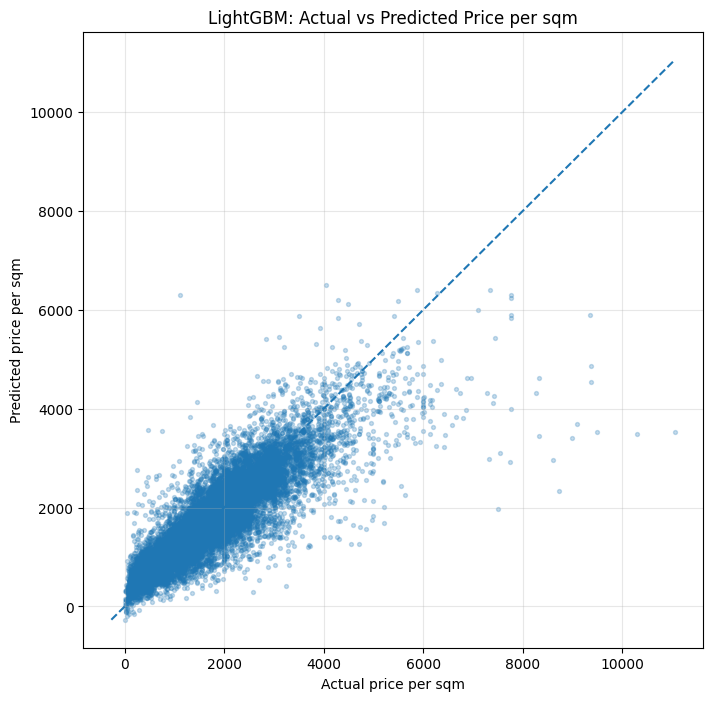

In [51]:
plt.figure(figsize=(8, 8))

plt.scatter(
    lgbm_error_df["actual_price_per_sqm"],
    lgbm_error_df["pred_price_per_sqm"],
    alpha=0.25,
    s=8
)

min_val = min(
    lgbm_error_df["actual_price_per_sqm"].min(),
    lgbm_error_df["pred_price_per_sqm"].min()
)

max_val = max(
    lgbm_error_df["actual_price_per_sqm"].max(),
    lgbm_error_df["pred_price_per_sqm"].max()
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.title("LightGBM: Actual vs Predicted Price per sqm")
plt.xlabel("Actual price per sqm")
plt.ylabel("Predicted price per sqm")
plt.grid(True, alpha=0.3)

plt.show()

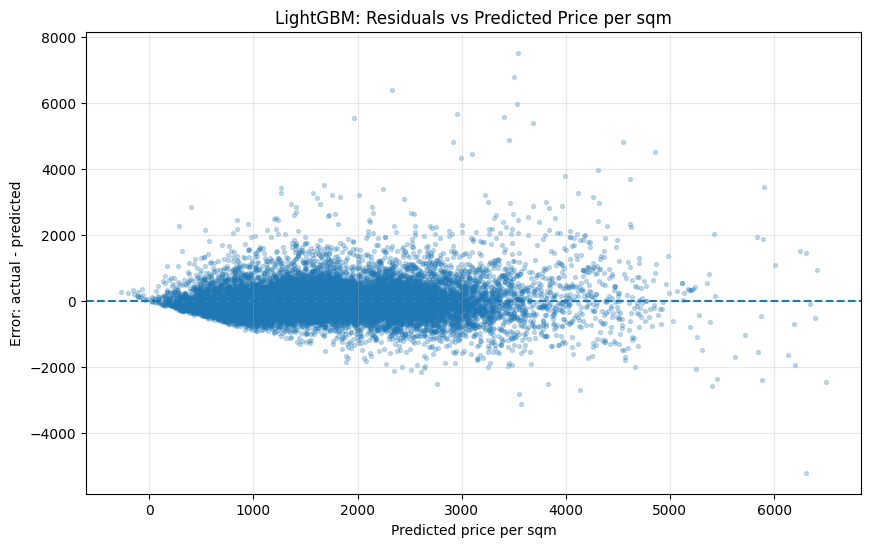

In [52]:
plt.figure(figsize=(10, 6))

plt.scatter(
    lgbm_error_df["pred_price_per_sqm"],
    lgbm_error_df["error"],
    alpha=0.25,
    s=8
)

plt.axhline(0, linestyle="--")

plt.title("LightGBM: Residuals vs Predicted Price per sqm")
plt.xlabel("Predicted price per sqm")
plt.ylabel("Error: actual - predicted")
plt.grid(True, alpha=0.3)

plt.show()

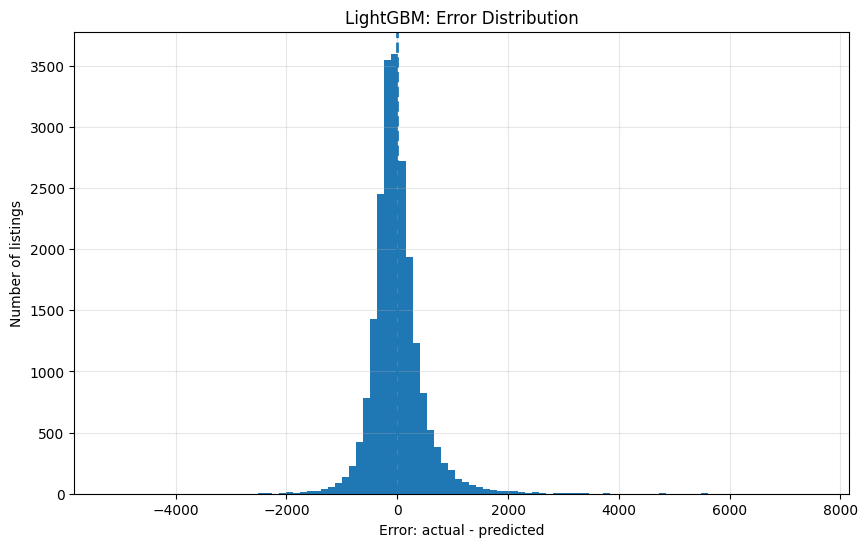

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(lgbm_error_df["error"], bins=100)

plt.axvline(0, linestyle="--", linewidth=2)

plt.title("LightGBM: Error Distribution")
plt.xlabel("Error: actual - predicted")
plt.ylabel("Number of listings")
plt.grid(True, alpha=0.3)

plt.show()

In [55]:
param_grid = {
    "model__n_estimators": [500, 800],
    "model__learning_rate": [0.03, 0.05],
    "model__num_leaves": [31, 63],
    "model__max_depth": [-1, 10],
    "model__min_child_samples": [20, 40],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8],
    "model__reg_lambda": [0.0, 1.0],
}

In [56]:
lgbm_grid_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            objective="regression",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

In [57]:
X_train_val_model = pd.concat([X_train_model, X_val_model], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

In [58]:
test_fold = np.concatenate([
    np.full(len(X_train_model), -1),
    np.zeros(len(X_val_model))
])

predefined_split = PredefinedSplit(test_fold)

In [59]:
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_grid_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=predefined_split,
    n_jobs=1,
    verbose=2,
    refit=True
)

grid_search_lgbm.fit(X_train_val_model, y_train_val)

Fitting 1 folds for each of 64 candidates, totalling 64 fits


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=-1, model__min_child_samples=20, model__n_estimators=500, model__num_leaves=31, model__reg_lambda=0.0, model__subsample=0.8; total time=  12.8s


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.03, model__max_depth=-1, model__min_child_samples=20, model__n_estimators=500, model__num_leaves=31, model__reg_lambda=1.0, model__subsample=0.8; total time=  12.1s


...

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=10, model__min_child_samples=40, model__n_estimators=800, model__num_leaves=63, model__reg_lambda=0.0, model__subsample=0.8; total time=  16.1s


C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=10, model__min_child_samples=40, model__n_estimators=800, model__num_leaves=63, model__reg_lambda=1.0, model__subsample=0.8; total time=  13.3s


,estimator,Pipeline(step...rbosity=-1))])
,param_grid,"{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.03, 0.05], 'model__max_depth': [-1, 10], 'model__min_child_samples': [20, 40], ...}"
,scoring,'neg_mean_absolute_error'
,n_jobs,1
,refit,True
,cv,"PredefinedSpl...ape=(85948,)))"
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('bin', ...), ...]"


In [60]:
# Check LightGBM GridSearchCV results


# Best params and best validation MAE from GridSearchCV
print("Best params:")
print(grid_search_lgbm.best_params_)

print("\nBest CV MAE:")
print(-grid_search_lgbm.best_score_)

# Full grid results
lgbm_grid_results_df = pd.DataFrame(grid_search_lgbm.cv_results_).copy()

# Convert negative MAE to positive MAE
lgbm_grid_results_df["MAE"] = -lgbm_grid_results_df["mean_test_score"]

# Select useful columns
result_cols = [
    "rank_test_score",
    "MAE",
    "mean_fit_time",
    "std_fit_time",
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_lambda",
]

lgbm_grid_summary_df = (
    lgbm_grid_results_df[result_cols]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

display(lgbm_grid_summary_df.head(20))

# Optional: compare best grid score to previous baseline LightGBM validation MAE
baseline_lgbm_mae = 317.002163

print("\nBaseline LightGBM MAE:", baseline_lgbm_mae)
print("Best grid MAE:", -grid_search_lgbm.best_score_)
print("Improvement:", baseline_lgbm_mae - (-grid_search_lgbm.best_score_))

Best params:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': -1, 'model__min_child_samples': 20, 'model__n_estimators': 800, 'model__num_leaves': 63, 'model__reg_lambda': 0.0, 'model__subsample': 0.8}

Best CV MAE:
300.35450831385697


,rank_test_score,MAE,mean_fit_time,std_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
0,1,300.354508,22.469763,0.0,800,0.05,63,-1,20,0.8,0.8,0.0
1,2,300.815475,23.283103,0.0,800,0.05,63,-1,20,0.8,0.8,1.0
2,3,305.356529,16.130896,0.0,500,0.05,63,-1,20,0.8,0.8,0.0
3,4,305.685657,24.284495,0.0,800,0.03,63,-1,20,0.8,0.8,0.0
4,5,305.752183,18.385420,0.0,500,0.05,63,-1,20,0.8,0.8,1.0
5,6,306.066368,28.334528,0.0,800,0.03,63,-1,20,0.8,0.8,1.0
6,7,306.868303,21.556466,0.0,800,0.05,63,-1,40,0.8,0.8,1.0
7,8,306.973988,25.577086,0.0,800,0.05,63,-1,40,0.8,0.8,0.0
8,9,307.989315,27.852574,0.0,800,0.05,63,10,20,0.8,0.8,0.0
9,10,308.759658,22.126192,0.0,800,0.05,63,10,20,0.8,0.8,1.0



Baseline LightGBM MAE: 317.002163
Best grid MAE: 300.35450831385697
Improvement: 16.647654686143028


In [61]:
# Get best params from GridSearchCV
best_params = grid_search_lgbm.best_params_

# Clean param names: remove "model__"
best_params_clean = {
    key.replace("model__", ""): value
    for key, value in best_params.items()
}

# Refit best model on train only, evaluate on val
best_lgbm_val_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", LGBMRegressor(
            **best_params_clean,
            objective="regression",
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ]
)

best_lgbm_val_model.fit(X_train_model, y_train)

y_val_pred_best = best_lgbm_val_model.predict(X_val_model)

best_lgbm_metrics = {
    "MAE": mean_absolute_error(y_val, y_val_pred_best),
    "RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred_best)),
    "R2": r2_score(y_val, y_val_pred_best),
}

best_lgbm_metrics

C:\Users\kamen.dimitrov\AppData\Local\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MAE': 300.35450831385697,
 'RMSE': np.float64(463.45925897916703),
 'R2': 0.7546966834650728}

In [62]:
# Analyze which LightGBM hyperparameter directions improved MAE
grid_df = pd.DataFrame(grid_search_lgbm.cv_results_).copy()
grid_df["MAE"] = -grid_df["mean_test_score"]

param_cols = [
    "param_model__n_estimators",
    "param_model__learning_rate",
    "param_model__num_leaves",
    "param_model__max_depth",
    "param_model__min_child_samples",
    "param_model__subsample",
    "param_model__colsample_bytree",
    "param_model__reg_lambda",
]

print("Best params:")
display(grid_search_lgbm.best_params_)

print("\nBest MAE:")
display(grid_df["MAE"].min())

# 1. Average MAE by each hyperparameter value
for col in param_cols:
    print(f"\nAverage MAE by {col}:")
    display(
        grid_df
        .groupby(col, dropna=False)
        .agg(
            mean_MAE=("MAE", "mean"),
            median_MAE=("MAE", "median"),
            best_MAE=("MAE", "min"),
            count=("MAE", "size"),
            mean_fit_time=("mean_fit_time", "mean"),
        )
        .sort_values("mean_MAE")
    )

# 2. Top 15 configurations
top_configs = (
    grid_df
    .sort_values("MAE")
    [
        ["MAE", "mean_fit_time"] + param_cols
    ]
    .reset_index(drop=True)
)

print("\nTop 15 configs:")
display(top_configs.head(15))

# 3. Compare best config vs baseline config, if baseline was in grid
baseline_params = {
    "param_model__n_estimators": 500,
    "param_model__learning_rate": 0.05,
    "param_model__num_leaves": 31,
    "param_model__max_depth": -1,
    "param_model__min_child_samples": 20,
    "param_model__subsample": 0.8,
    "param_model__colsample_bytree": 0.8,
    "param_model__reg_lambda": 0.0,
}

baseline_mask = pd.Series(True, index=grid_df.index)

for col, value in baseline_params.items():
    if col in grid_df.columns:
        baseline_mask &= grid_df[col].astype(str).eq(str(value))

baseline_grid_rows = grid_df[baseline_mask]

print("\nBaseline-like rows found in grid:")
display(
    baseline_grid_rows[["MAE", "mean_fit_time"] + param_cols]
    if len(baseline_grid_rows) > 0
    else "No exact baseline config found in this grid."
)

Best params:


{'model__colsample_bytree': 0.8,
 'model__learning_rate': 0.05,
 'model__max_depth': -1,
 'model__min_child_samples': 20,
 'model__n_estimators': 800,
 'model__num_leaves': 63,
 'model__reg_lambda': 0.0,
 'model__subsample': 0.8}


Best MAE:


np.float64(300.35450831385697)


Average MAE by param_model__n_estimators:


...

,mean_MAE,median_MAE,best_MAE,count,mean_fit_time
param_model__reg_lambda,,,,,
0.0,317.188672,316.835837,300.354508,32,15.979029
1.0,317.595536,317.531661,300.815475,32,16.244946



Top 15 configs:


,MAE,mean_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
0,300.354508,22.469763,800,0.05,63,-1,20,0.8,0.8,0.0
1,300.815475,23.283103,800,0.05,63,-1,20,0.8,0.8,1.0
2,305.356529,16.130896,500,0.05,63,-1,20,0.8,0.8,0.0
3,305.685657,24.284495,800,0.03,63,-1,20,0.8,0.8,0.0
4,305.752183,18.385420,500,0.05,63,-1,20,0.8,0.8,1.0
5,306.066368,28.334528,800,0.03,63,-1,20,0.8,0.8,1.0
6,306.868303,21.556466,800,0.05,63,-1,40,0.8,0.8,1.0
7,306.973988,25.577086,800,0.05,63,-1,40,0.8,0.8,0.0
8,307.989315,27.852574,800,0.05,63,10,20,0.8,0.8,0.0
9,308.759658,22.126192,800,0.05,63,10,20,0.8,0.8,1.0



Baseline-like rows found in grid:


,MAE,mean_fit_time,param_model__n_estimators,param_model__learning_rate,param_model__num_leaves,param_model__max_depth,param_model__min_child_samples,param_model__subsample,param_model__colsample_bytree,param_model__reg_lambda
32,317.002163,12.33533,500,0.05,31,-1,20,0.8,0.8,0.0
